In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
y_original = df['Exited'].copy()

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df = pd.get_dummies(df, drop_first=True)

print(f"Dataset: {df.shape[0]:,} registros, {df.shape[1]} variables")
print(f"Tasa de churn global: {y_original.mean():.2%}")

X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"\nFeatures para clustering: {list(X.columns)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Datos escalados con StandardScaler")

Dataset: 10,000 registros, 12 variables
Tasa de churn global: 20.37%

Features para clustering: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
Datos escalados con StandardScaler


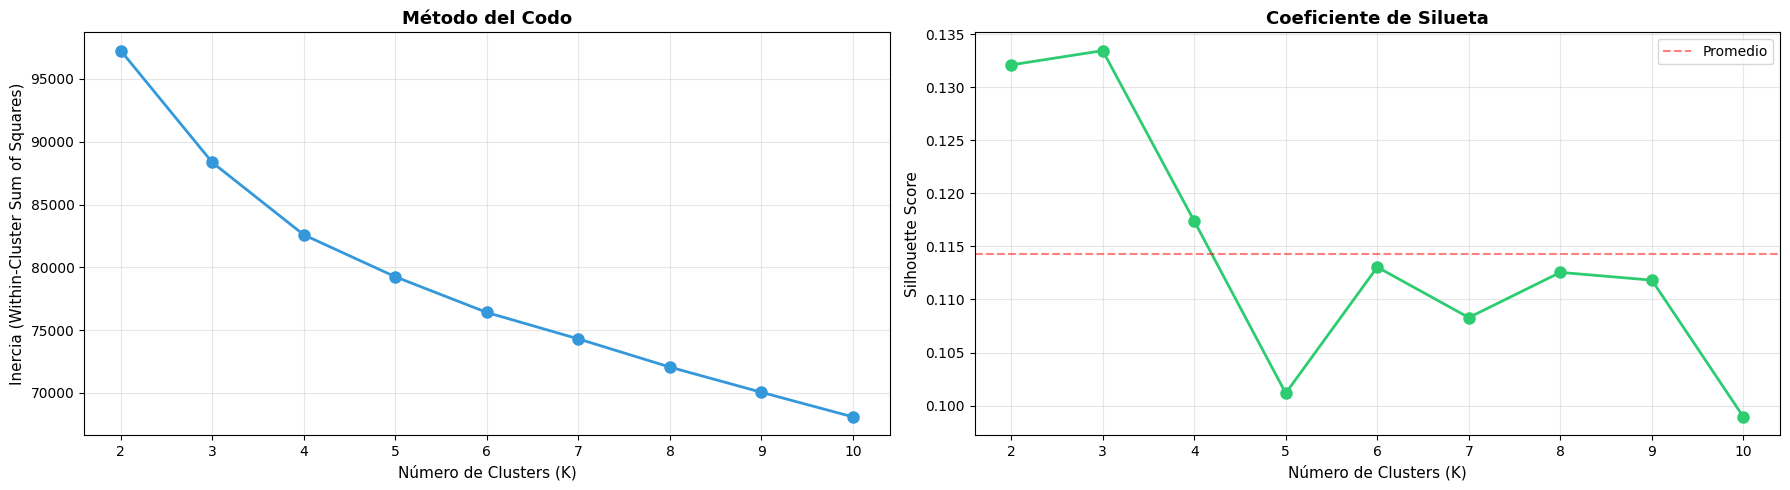


ANÁLISIS DE K ÓPTIMO:

   Mejor K según Silhouette: 3 (score: 0.1334)
   Recomendación basada en el codo: K=3 o K=4

K ÓPTIMO SELECCIONADO: 3


In [ ]:
K_range = range(2, 11)
inertia_values = []
silhouette_scores = []
davies_bouldin_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(K_range, inertia_values, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inercia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Método del Codo', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(K_range)

axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#2ecc71')
axes[1].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Coeficiente de Silueta', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(K_range)
axes[1].axhline(y=np.mean(silhouette_scores), color='red', linestyle='--', alpha=0.5, label='Promedio')
axes[1].legend()

plt.tight_layout()
plt.show()

optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]

print(f"\nANÁLISIS DE K ÓPTIMO:")
print(f"\n   Mejor K según Silhouette: {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
print(f"   Recomendación basada en el codo: K=3 o K=4")

k_opt = 3
print(f"\nK ÓPTIMO SELECCIONADO: {k_opt}")

In [ ]:
kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df['Cluster_KMeans'] = cluster_labels

final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_db = davies_bouldin_score(X_scaled, cluster_labels)

print(f"\nModelo K-Means entrenado")
print(f"   Silhouette Score: {final_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {final_db:.4f}")

print(f"\nDISTRIBUCIÓN DE CLUSTERS:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(cluster_labels) * 100
    print(f"   Cluster {cluster_id}: {count:,} clientes ({pct:.1f}%)")

silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
for cluster_id in range(k_opt):
    cluster_silhouette = silhouette_vals[cluster_labels == cluster_id]
    print(f"   Silhouette promedio Cluster {cluster_id}: {cluster_silhouette.mean():.4f}")



Modelo K-Means entrenado
   Silhouette Score: 0.1334
   Davies-Bouldin Index: 2.4771

DISTRIBUCIÓN DE CLUSTERS:
   Cluster 0: 2,509 clientes (25.1%)
   Cluster 1: 5,014 clientes (50.1%)
   Cluster 2: 2,477 clientes (24.8%)
   Silhouette promedio Cluster 0: 0.1679
   Silhouette promedio Cluster 1: 0.1156
   Silhouette promedio Cluster 2: 0.1347


In [17]:
eps_values = [2.0, 2.5, 3.0]
min_samples = 5

print(f"\nProbando diferentes valores de eps (min_samples={min_samples})...")

best_eps = None
best_n_clusters = 0
best_noise_ratio = 1.0

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)
    noise_ratio = n_noise / len(db_labels)
    
    print(f"\n   eps={eps}:")
    print(f"      Clusters encontrados: {n_clusters}")
    print(f"      Puntos de ruido: {n_noise:,} ({noise_ratio:.1%})")

    if n_clusters > 1 and 0.05 < noise_ratio < 0.15:
        if best_eps is None or abs(noise_ratio - 0.10) < abs(best_noise_ratio - 0.10):
            best_eps = eps
            best_n_clusters = n_clusters
            best_noise_ratio = noise_ratio

if best_eps is None:
    best_eps = 2.5

print(f"\nPARÁMETROS SELECCIONADOS: eps={best_eps}, min_samples={min_samples}")

dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples)
db_labels = dbscan_final.fit_predict(X_scaled)

df['Cluster_DBSCAN'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print(f"\nDBSCAN - Resultados:")
print(f"   Clusters encontrados: {n_clusters_db}")
print(f"   Puntos de ruido (outliers): {n_noise_db:,} ({n_noise_db/len(db_labels):.1%})")

print(f"\nDISTRIBUCIÓN DE CLUSTERS DBSCAN:")
db_cluster_counts = pd.Series(db_labels).value_counts().sort_index()
for cluster_id, count in db_cluster_counts.items():
    pct = count / len(db_labels) * 100
    label = "Ruido" if cluster_id == -1 else f"Cluster {cluster_id}"
    print(f"   {label}: {count:,} clientes ({pct:.1f}%)")


Probando diferentes valores de eps (min_samples=5)...

   eps=2.0:
      Clusters encontrados: 24
      Puntos de ruido: 142 (1.4%)

   eps=2.5:
      Clusters encontrados: 1
      Puntos de ruido: 28 (0.3%)

   eps=3.0:
      Clusters encontrados: 1
      Puntos de ruido: 0 (0.0%)

PARÁMETROS SELECCIONADOS: eps=2.5, min_samples=5

DBSCAN - Resultados:
   Clusters encontrados: 1
   Puntos de ruido (outliers): 28 (0.3%)

DISTRIBUCIÓN DE CLUSTERS DBSCAN:
   Ruido: 28 clientes (0.3%)
   Cluster 0: 9,972 clientes (99.7%)


In [39]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\nVARIANZA EXPLICADA POR COMPONENTE:")
for i, (var, cum_var) in enumerate(zip(explained_variance[:5], cumulative_variance[:5]), 1):
    print(f"   PC{i}: {var:.4f} ({var*100:.2f}%) - Acumulada: {cum_var:.4f} ({cum_var*100:.2f}%)")

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\n   Componentes para 80% varianza: {n_components_80}")
print(f"   Componentes para 90% varianza: {n_components_90}")

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"\nPCA 2D entrenado")
print(f"   Varianza explicada: {sum(pca_2d.explained_variance_ratio_):.4f} ({sum(pca_2d.explained_variance_ratio_)*100:.2f}%)")


VARIANZA EXPLICADA POR COMPONENTE:
   PC1: 0.1504 (15.04%) - Acumulada: 0.1504 (15.04%)
   PC2: 0.1033 (10.33%) - Acumulada: 0.2537 (25.37%)
   PC3: 0.0995 (9.95%) - Acumulada: 0.3532 (35.32%)
   PC4: 0.0930 (9.30%) - Acumulada: 0.4463 (44.63%)
   PC5: 0.0916 (9.16%) - Acumulada: 0.5378 (53.78%)

   Componentes para 80% varianza: 8
   Componentes para 90% varianza: 10

PCA 2D entrenado
   Varianza explicada: 0.2537 (25.37%)


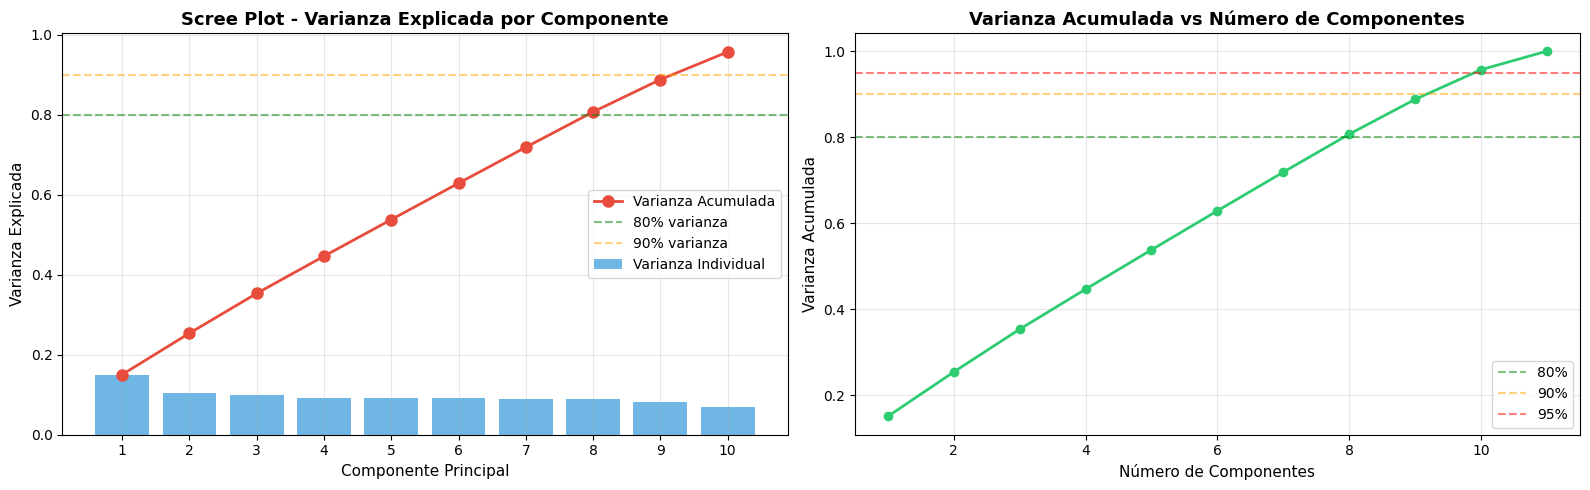

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, len(explained_variance[:10])+1), explained_variance[:10], 
            alpha=0.7, color='#3498db', label='Varianza Individual')
axes[0].plot(range(1, len(cumulative_variance[:10])+1), cumulative_variance[:10],
             marker='o', color='#e74c3c', linewidth=2, markersize=8, label='Varianza Acumulada')
axes[0].axhline(y=0.80, color='green', linestyle='--', alpha=0.5, label='80% varianza')
axes[0].axhline(y=0.90, color='orange', linestyle='--', alpha=0.5, label='90% varianza')
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Varianza Explicada', fontsize=11)
axes[0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, 11))

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance,
             marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[1].axhline(y=0.80, color='green', linestyle='--', alpha=0.5, label='80%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', alpha=0.5, label='90%')
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95%')
axes[1].set_xlabel('Número de Componentes', fontsize=11)
axes[1].set_ylabel('Varianza Acumulada', fontsize=11)
axes[1].set_title('Varianza Acumulada vs Número de Componentes', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [40]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
loadings['Magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
loadings = loadings.sort_values('Magnitude', ascending=False)

print(f"\nTOP 10 VARIABLES MÁS INFLUYENTES EN PC1 Y PC2:")
print(loadings.head(10))


TOP 10 VARIABLES MÁS INFLUYENTES EN PC1 Y PC2:
                        PC1       PC2  Magnitude
NumOfProducts     -0.297038  0.627182   0.693966
Geography_Germany  0.598445  0.267883   0.655666
Balance            0.598143 -0.255401   0.650388
Geography_Spain   -0.432718 -0.434924   0.613517
IsActiveMember    -0.032954 -0.299974   0.301778
Age                0.080287 -0.277177   0.288571
Gender_Male       -0.017901 -0.201571   0.202364
Tenure            -0.020295  0.167275   0.168501
HasCrCard          0.001576  0.166233   0.166241
EstimatedSalary    0.018591  0.131598   0.132904


In [41]:
perplexity_value = 30
tsne = TSNE(n_components=2, random_state=42,
            perplexity=perplexity_value,
            max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE calculado (perplexity={perplexity_value})")

t-SNE calculado (perplexity=30)


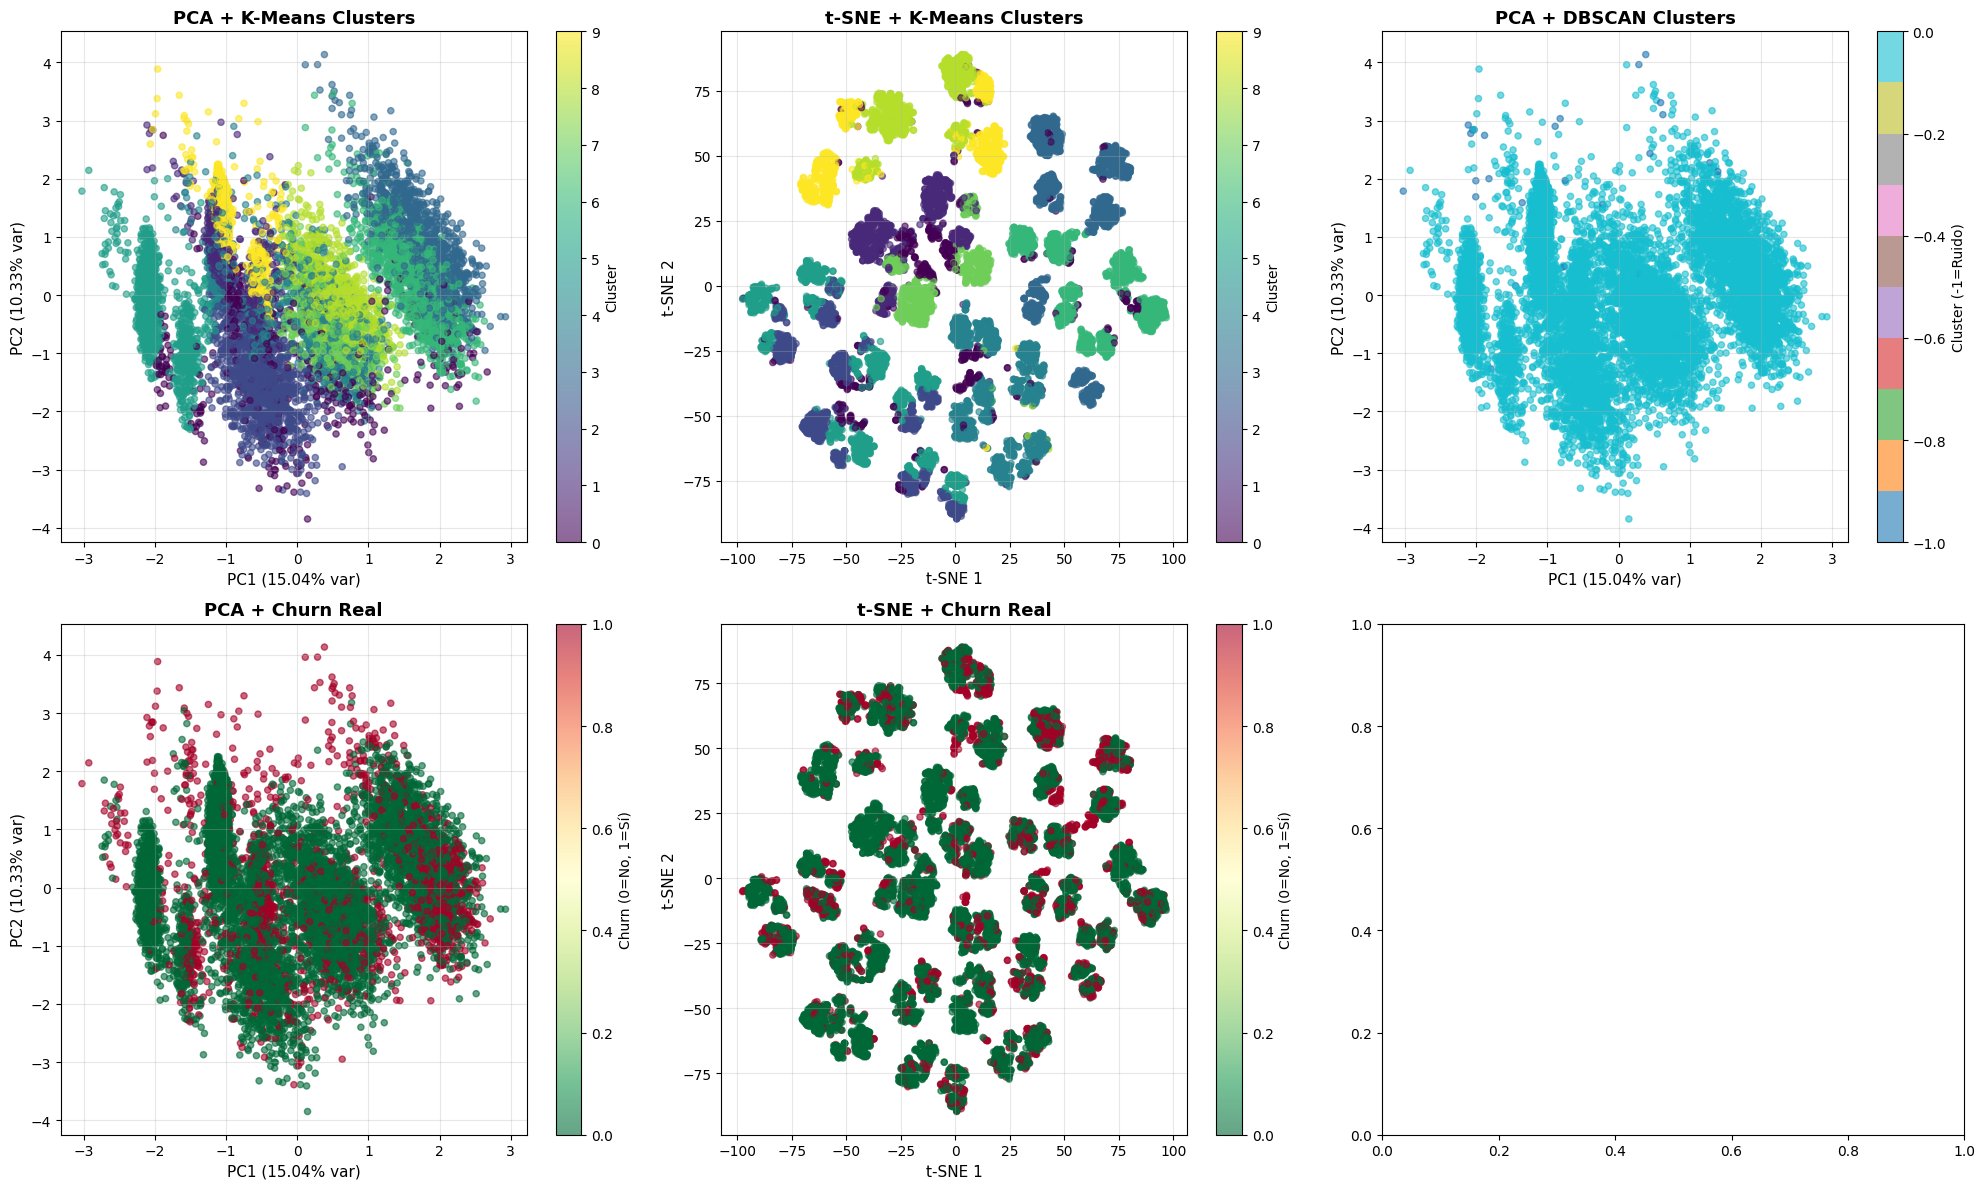

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

colors_kmeans = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                               cmap='viridis', alpha=0.6, s=20)
axes[0, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)', fontsize=11)
axes[0, 0].set_title('PCA + K-Means Clusters', fontsize=13, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')
axes[0, 0].grid(alpha=0.3)

scatter2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels,
                               cmap='viridis', alpha=0.6, s=20)
axes[0, 1].set_xlabel('t-SNE 1', fontsize=11)
axes[0, 1].set_ylabel('t-SNE 2', fontsize=11)
axes[0, 1].set_title('t-SNE + K-Means Clusters', fontsize=13, fontweight='bold')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')
axes[0, 1].grid(alpha=0.3)

scatter3 = axes[0, 2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels,
                               cmap='tab10', alpha=0.6, s=20)
axes[0, 2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)', fontsize=11)
axes[0, 2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)', fontsize=11)
axes[0, 2].set_title('PCA + DBSCAN Clusters', fontsize=13, fontweight='bold')
plt.colorbar(scatter3, ax=axes[0, 2], label='Cluster (-1=Ruido)')
axes[0, 2].grid(alpha=0.3)

scatter4 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_original,
                               cmap='RdYlGn_r', alpha=0.6, s=20)
axes[1, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)', fontsize=11)
axes[1, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)', fontsize=11)
axes[1, 0].set_title('PCA + Churn Real', fontsize=13, fontweight='bold')
plt.colorbar(scatter4, ax=axes[1, 0], label='Churn (0=No, 1=Sí)')
axes[1, 0].grid(alpha=0.3)

scatter5 = axes[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_original,
                               cmap='RdYlGn_r', alpha=0.6, s=20)
axes[1, 1].set_xlabel('t-SNE 1', fontsize=11)
axes[1, 1].set_ylabel('t-SNE 2', fontsize=11)
axes[1, 1].set_title('t-SNE + Churn Real', fontsize=13, fontweight='bold')
plt.colorbar(scatter5, ax=axes[1, 1], label='Churn (0=No, 1=Sí)')
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [43]:
df['Churn'] = y_original

print("\nTASA DE CHURN POR CLUSTER (K-MEANS):")
churn_by_cluster_kmeans = df.groupby('Cluster_KMeans')['Churn'].agg(['mean', 'count'])
churn_by_cluster_kmeans.columns = ['Tasa_Churn', 'Num_Clientes']
churn_by_cluster_kmeans['Tasa_Churn_Pct'] = churn_by_cluster_kmeans['Tasa_Churn'] * 100

for idx, row in churn_by_cluster_kmeans.iterrows():
    print(f"   Cluster {idx}: {row['Tasa_Churn_Pct']:.2f}% churn ({row['Num_Clientes']:,} clientes)")

print("\nTASA DE CHURN POR CLUSTER (DBSCAN):")
churn_by_cluster_dbscan = df.groupby('Cluster_DBSCAN')['Churn'].agg(['mean', 'count'])
churn_by_cluster_dbscan.columns = ['Tasa_Churn', 'Num_Clientes']
churn_by_cluster_dbscan['Tasa_Churn_Pct'] = churn_by_cluster_dbscan['Tasa_Churn'] * 100

for idx, row in churn_by_cluster_dbscan.iterrows():
    label = "Ruido" if idx == -1 else f"Cluster {idx}"
    print(f"   {label}: {row['Tasa_Churn_Pct']:.2f}% churn ({row['Num_Clientes']:,} clientes)")


TASA DE CHURN POR CLUSTER (K-MEANS):
   Cluster 0: 32.44% churn (2,509.0 clientes)
   Cluster 1: 16.15% churn (5,014.0 clientes)
   Cluster 2: 16.67% churn (2,477.0 clientes)

TASA DE CHURN POR CLUSTER (DBSCAN):
   Ruido: 92.86% churn (28.0 clientes)
   Cluster 0: 20.17% churn (9,972.0 clientes)


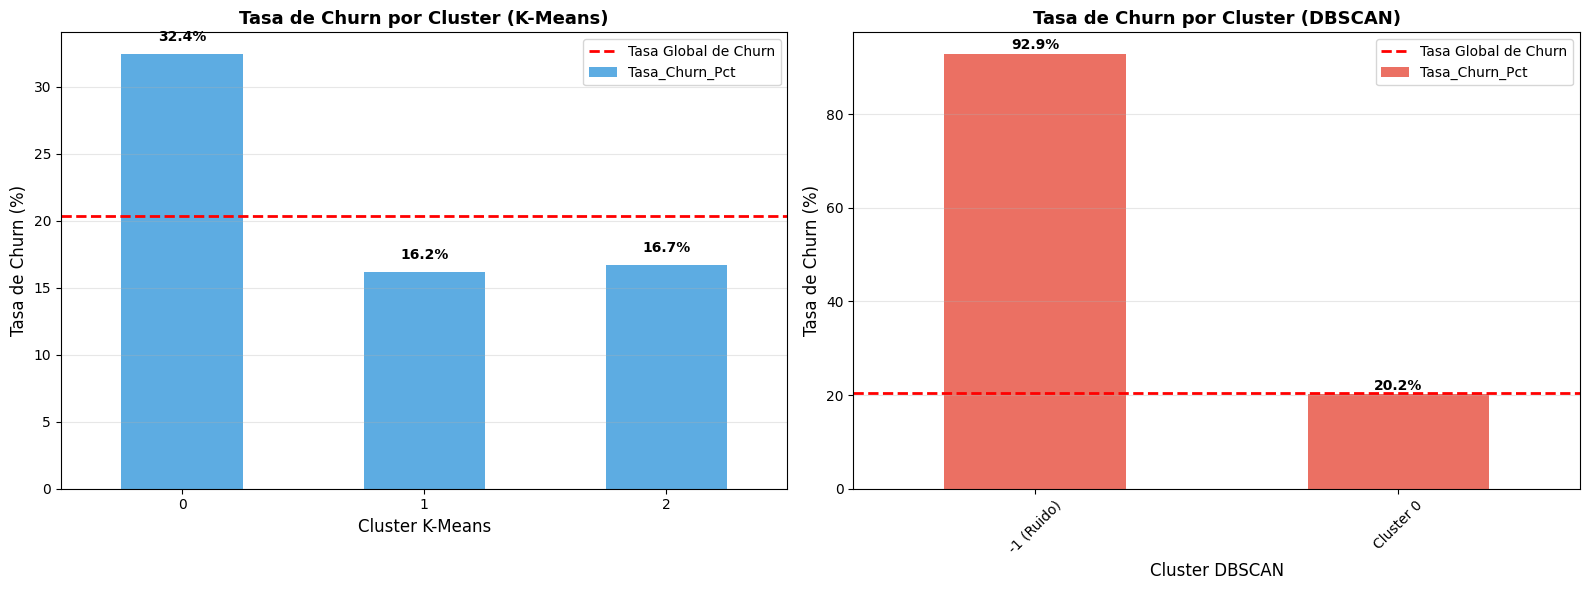

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

churn_by_cluster_kmeans['Tasa_Churn_Pct'].plot(kind='bar', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].axhline(y=y_original.mean()*100, color='red', linestyle='--', linewidth=2, label='Tasa Global de Churn')
axes[0].set_xlabel('Cluster K-Means', fontsize=12)
axes[0].set_ylabel('Tasa de Churn (%)', fontsize=12)
axes[0].set_title('Tasa de Churn por Cluster (K-Means)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(churn_by_cluster_kmeans['Tasa_Churn_Pct']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

churn_by_cluster_dbscan['Tasa_Churn_Pct'].plot(kind='bar', ax=axes[1], color='#e74c3c', alpha=0.8)
axes[1].axhline(y=y_original.mean()*100, color='red', linestyle='--', linewidth=2, label='Tasa Global de Churn')
axes[1].set_xlabel('Cluster DBSCAN', fontsize=12)
axes[1].set_ylabel('Tasa de Churn (%)', fontsize=12)
axes[1].set_title('Tasa de Churn por Cluster (DBSCAN)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(['-1 (Ruido)' if x.get_text() == '-1' else f'Cluster {x.get_text()}' 
                         for x in axes[1].get_xticklabels()], rotation=45)
for i, v in enumerate(churn_by_cluster_dbscan['Tasa_Churn_Pct']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


CARACTERÍSTICAS PROMEDIO POR CLUSTER:

CLUSTER 0 (n=2,509, Churn=32.4%)
------------------------------------------------------------
  Edad promedio: 39.8 años
  Balance promedio: $119,730
  Credit Score promedio: 651
  Salario estimado: $101,113
  Productos promedio: 1.52
  Antigüedad promedio: 5.0 años
  % Miembros activos: 49.7%

  Distribución geográfica:
    Germany: 100.0%

  Distribución de género:
    Male: 52.5%
    Female: 47.5%

CLUSTER 1 (n=5,014, Churn=16.2%)
------------------------------------------------------------
  Edad promedio: 38.5 años
  Balance promedio: $62,093
  Credit Score promedio: 650
  Salario estimado: $99,899
  Productos promedio: 1.53
  Antigüedad promedio: 5.0 años
  % Miembros activos: 51.7%

  Distribución geográfica:
    France: 100.0%

  Distribución de género:
    Male: 54.9%
    Female: 45.1%

CLUSTER 2 (n=2,477, Churn=16.7%)
------------------------------------------------------------
  Edad promedio: 38.9 años
  Balance promedio: $61,818
  Cr

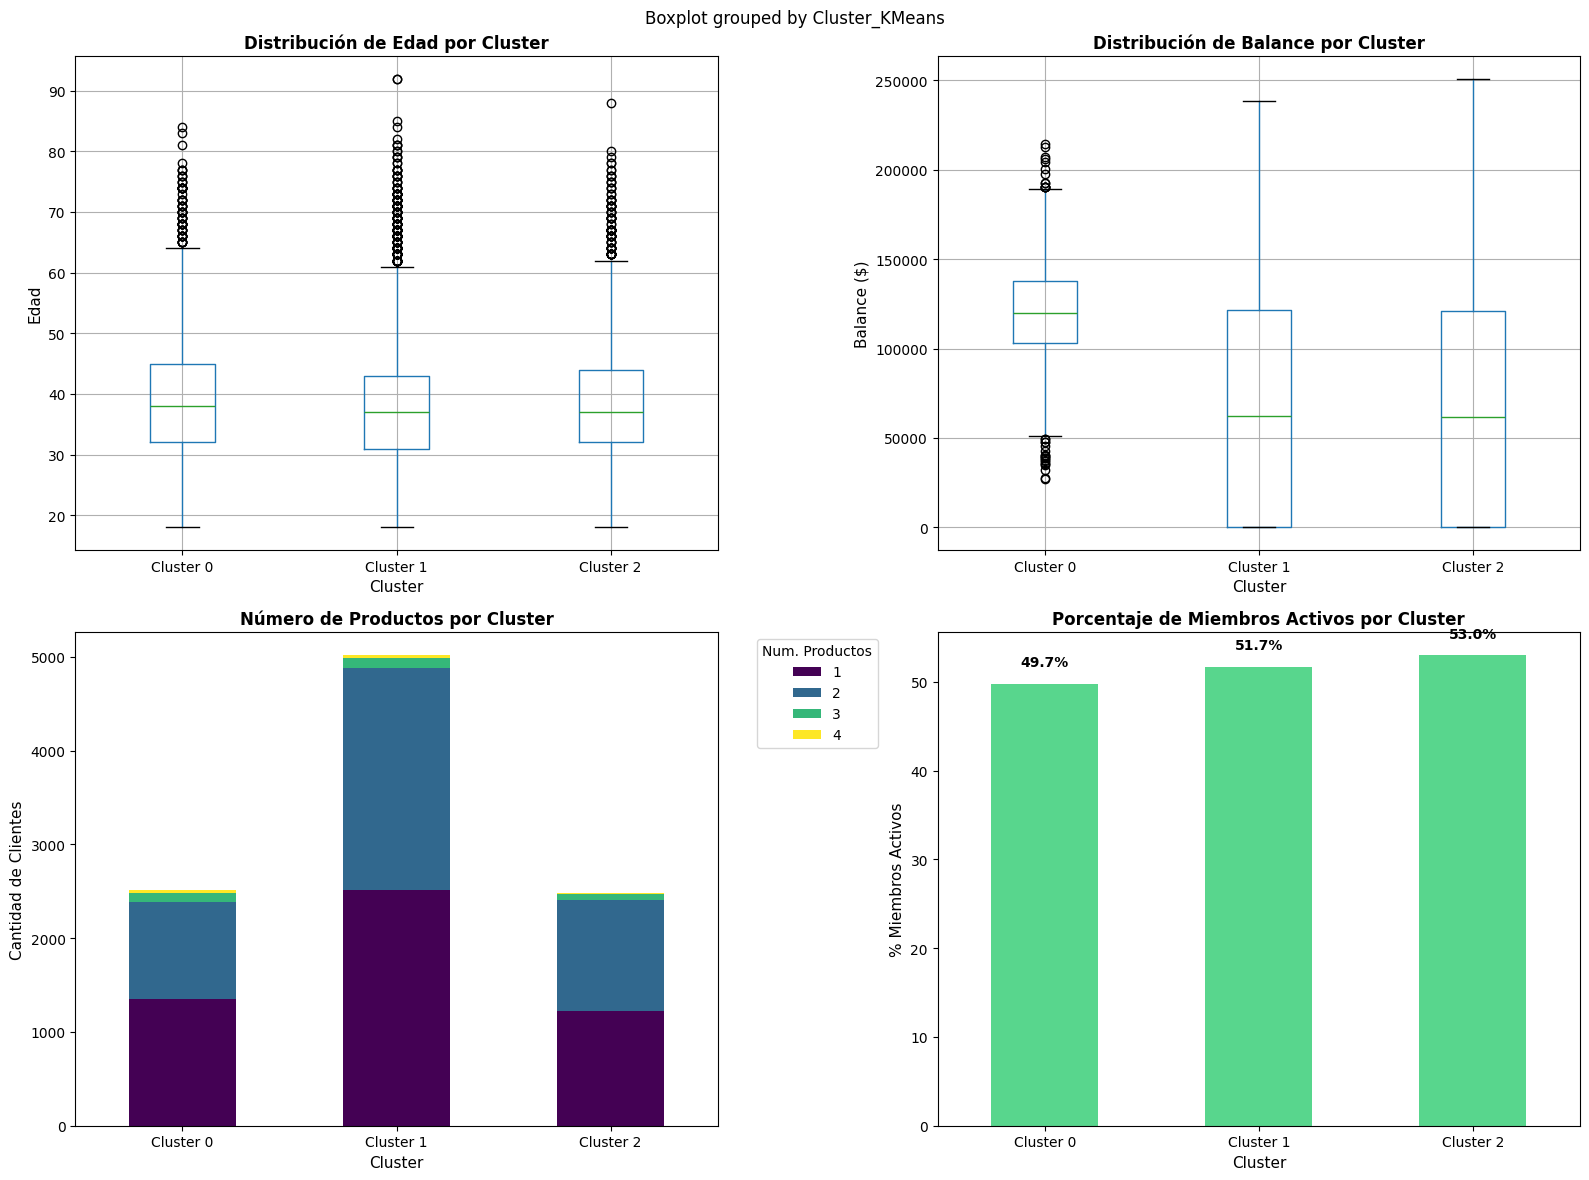

In [32]:
df_profile = pd.read_csv('Churn_Modelling.csv')
df_profile['Cluster_KMeans'] = df['Cluster_KMeans'].values
df_profile['Churn'] = y_original.values

profile_vars = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 
                'NumOfProducts', 'Tenure', 'IsActiveMember', 'Geography', 'Gender']

print("\nCARACTERÍSTICAS PROMEDIO POR CLUSTER:\n")

for cluster_id in range(k_opt):
    cluster_data = df_profile[df_profile['Cluster_KMeans'] == cluster_id]
    churn_rate = cluster_data['Churn'].mean() * 100

    print(f"CLUSTER {cluster_id} (n={len(cluster_data):,}, Churn={churn_rate:.1f}%)")
    print(f"{'-'*60}")

    print(f"  Edad promedio: {cluster_data['Age'].mean():.1f} años")
    print(f"  Balance promedio: ${cluster_data['Balance'].mean():,.0f}")
    print(f"  Credit Score promedio: {cluster_data['CreditScore'].mean():.0f}")
    print(f"  Salario estimado: ${cluster_data['EstimatedSalary'].mean():,.0f}")
    print(f"  Productos promedio: {cluster_data['NumOfProducts'].mean():.2f}")
    print(f"  Antigüedad promedio: {cluster_data['Tenure'].mean():.1f} años")
    print(f"  % Miembros activos: {cluster_data['IsActiveMember'].mean()*100:.1f}%")

    print(f"\n  Distribución geográfica:")
    geo_dist = cluster_data['Geography'].value_counts(normalize=True) * 100
    for country, pct in geo_dist.items():
        print(f"    {country}: {pct:.1f}%")

    print(f"\n  Distribución de género:")
    gender_dist = cluster_data['Gender'].value_counts(normalize=True) * 100
    for gender, pct in gender_dist.items():
        print(f"    {gender}: {pct:.1f}%")
    
    print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cluster_ids = sorted(df_profile['Cluster_KMeans'].unique())
n_clusters_profile = len(cluster_ids)
cluster_labels = [f'Cluster {c}' for c in cluster_ids]

df_profile.boxplot(column='Age', by='Cluster_KMeans', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Edad por Cluster', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cluster', fontsize=11)
axes[0, 0].set_ylabel('Edad', fontsize=11)
axes[0, 0].set_xticks(range(1, n_clusters_profile + 1))
axes[0, 0].set_xticklabels(cluster_labels, rotation=0)

df_profile.boxplot(column='Balance', by='Cluster_KMeans', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Balance por Cluster', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cluster', fontsize=11)
axes[0, 1].set_ylabel('Balance ($)', fontsize=11)
axes[0, 1].set_xticks(range(1, n_clusters_profile + 1))
axes[0, 1].set_xticklabels(cluster_labels, rotation=0)

products_by_cluster = df_profile.groupby(['Cluster_KMeans', 'NumOfProducts']).size().unstack(fill_value=0)
products_by_cluster = products_by_cluster.reindex(index=cluster_ids) 
products_by_cluster.plot(kind='bar', ax=axes[1, 0], stacked=True, colormap='viridis')
axes[1, 0].set_title('Número de Productos por Cluster', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cluster', fontsize=11)
axes[1, 0].set_ylabel('Cantidad de Clientes', fontsize=11)
axes[1, 0].legend(title='Num. Productos', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].set_xticks(range(len(products_by_cluster.index)))
axes[1, 0].set_xticklabels(cluster_labels, rotation=0)

active_by_cluster = df_profile.groupby('Cluster_KMeans')['IsActiveMember'].mean() * 100
active_by_cluster = active_by_cluster.reindex(cluster_ids) 
active_by_cluster.plot(kind='bar', ax=axes[1, 1], color='#2ecc71', alpha=0.8)
axes[1, 1].set_title('Porcentaje de Miembros Activos por Cluster', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cluster', fontsize=11)
axes[1, 1].set_ylabel('% Miembros Activos', fontsize=11)
axes[1, 1].set_xticks(range(len(active_by_cluster)))
axes[1, 1].set_xticklabels(cluster_labels, rotation=0)
for i, v in enumerate(active_by_cluster):
    axes[1, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
high_risk_cluster = churn_by_cluster_kmeans['Tasa_Churn_Pct'].idxmax()
high_risk_rate = churn_by_cluster_kmeans.loc[high_risk_cluster, 'Tasa_Churn_Pct']
high_risk_count = churn_by_cluster_kmeans.loc[high_risk_cluster, 'Num_Clientes']

low_risk_cluster = churn_by_cluster_kmeans['Tasa_Churn_Pct'].idxmin()
low_risk_rate = churn_by_cluster_kmeans.loc[low_risk_cluster, 'Tasa_Churn_Pct']
low_risk_count = churn_by_cluster_kmeans.loc[low_risk_cluster, 'Num_Clientes']

print(f"\nCLUSTERS IDENTIFICADOS:")
print(f"\nCLUSTER DE ALTO RIESGO: Cluster {high_risk_cluster}")
print(f"   - Tasa de churn: {high_risk_rate:.2f}%")
print(f"   - Número de clientes: {high_risk_count:,}")
print(f"   - Churn esperado: {int(high_risk_count * high_risk_rate / 100):,} clientes")

print(f"\nCLUSTER DE BAJO RIESGO: Cluster {low_risk_cluster}")
print(f"   - Tasa de churn: {low_risk_rate:.2f}%")
print(f"   - Número de clientes: {low_risk_count:,}")

print(f"\nHALLAZGOS CLAVE:")

for cluster_id in range(k_opt):
    cluster_data = df_profile[df_profile['Cluster_KMeans'] == cluster_id]
    churn_rate = cluster_data['Churn'].mean() * 100
    
    print(f"\n   Cluster {cluster_id} - Perfil:")

    avg_age = cluster_data['Age'].mean()
    avg_balance = cluster_data['Balance'].mean()
    avg_products = cluster_data['NumOfProducts'].mean()
    pct_active = cluster_data['IsActiveMember'].mean() * 100
    
    if avg_age > 50:
        print(f"      • Clientes de mayor edad (promedio: {avg_age:.1f} años)")
    elif avg_age < 35:
        print(f"      • Clientes jóvenes (promedio: {avg_age:.1f} años)")
    else:
        print(f"      • Edad media (promedio: {avg_age:.1f} años)")
    
    if avg_balance > 100000:
        print(f"      • Balance alto (promedio: ${avg_balance:,.0f})")
    elif avg_balance < 50000:
        print(f"      • Balance bajo (promedio: ${avg_balance:,.0f})")
    else:
        print(f"      • Balance medio (promedio: ${avg_balance:,.0f})")
    
    if avg_products > 2:
        print(f"      • Multi-producto (promedio: {avg_products:.2f} productos)")
    else:
        print(f"      • Bajo engagement (promedio: {avg_products:.2f} productos)")
    
    if pct_active < 40:
        print(f"      • Baja actividad ({pct_active:.1f}% activos)")
    elif pct_active > 60:
        print(f"      • Alta actividad ({pct_active:.1f}% activos)")
    else:
        print(f"      • Actividad media ({pct_active:.1f}% activos)")
    
    print(f"      • Tasa de churn: {churn_rate:.1f}%")

print(f"\nRECOMENDACIONES ESTRATÉGICAS:")

print(f"\n   1. SEGMENTACIÓN PARA RETENCIÓN:")
print(f"      - Priorizar acciones en Cluster {high_risk_cluster} (mayor tasa de churn)")
print(f"      - Diseñar estrategias diferenciadas por cluster")
print(f"      - Asignar recursos según riesgo de churn")

print(f"\n   2. FEATURE ENGINEERING:")
print(f"      - Incorporar 'Cluster_ID' como feature en modelos supervisados")
print(f"      - Crear variables de distancia al centroide de cada cluster")
print(f"      - Usar pertenencia a cluster como indicador de riesgo")

print(f"\n   3. INSIGHTS PARA EL NEGOCIO:")
print(f"      - Análisis detallado de características del Cluster {high_risk_cluster}")
print(f"      - Benchmarking con Cluster {low_risk_cluster} (menor churn)")
print(f"      - Identificar factores protectores y de riesgo")

print(f"\n   4. PRÓXIMOS PASOS:")
print(f"      - A/B testing de estrategias de retención por cluster")
print(f"      - Monitoreo de migración entre clusters")
print(f"      - Re-clustering periódico para actualizar segmentos")

print(f"\n   5. INTEGRACIÓN CON MODELOS SUPERVISADOS:")
print(f"      - Entrenar modelos específicos por cluster")
print(f"      - Combinar clustering + gradient boosting para mejor precisión")
print(f"      - Usar clusters para explicabilidad de predicciones")


CLUSTERS IDENTIFICADOS:

CLUSTER DE ALTO RIESGO: Cluster 0
   - Tasa de churn: 32.44%
   - Número de clientes: 2,509
   - Churn esperado: 814 clientes

CLUSTER DE BAJO RIESGO: Cluster 1
   - Tasa de churn: 16.15%
   - Número de clientes: 5,014

HALLAZGOS CLAVE:

   Cluster 0 - Perfil:
      • Edad media (promedio: 39.8 años)
      • Balance alto (promedio: $119,730)
      • Bajo engagement (promedio: 1.52 productos)
      • Actividad media (49.7% activos)
      • Tasa de churn: 32.4%

   Cluster 1 - Perfil:
      • Edad media (promedio: 38.5 años)
      • Balance medio (promedio: $62,093)
      • Bajo engagement (promedio: 1.53 productos)
      • Actividad media (51.7% activos)
      • Tasa de churn: 16.2%

   Cluster 2 - Perfil:
      • Edad media (promedio: 38.9 años)
      • Balance medio (promedio: $61,818)
      • Bajo engagement (promedio: 1.54 productos)
      • Actividad media (53.0% activos)
      • Tasa de churn: 16.7%

RECOMENDACIONES ESTRATÉGICAS:

   1. SEGMENTACIÓN PARA 

In [ ]:
df_export = df_profile[['RowNumber', 'CustomerId']].copy()
df_export['Cluster_KMeans'] = cluster_labels
df_export['Cluster_DBSCAN'] = db_labels
df_export['Churn'] = y_original

output_file = 'clustering_results.csv'
df_export.to_csv(output_file, index=False)
print(f"\n✓ Resultados guardados en: {output_file}")

cluster_summary = df_profile.groupby('Cluster_KMeans').agg({
    'Age': 'mean',
    'Balance': 'mean',
    'CreditScore': 'mean',
    'NumOfProducts': 'mean',
    'IsActiveMember': 'mean',
    'Churn': ['mean', 'count']
}).round(2)

cluster_summary.columns = ['Edad_Media', 'Balance_Medio', 'CreditScore_Medio', 
                           'NumProductos_Medio', 'PctActivos', 'TasaChurn', 'NumClientes']
cluster_summary.to_csv('cluster_profiles.csv')
print(f"✓ Perfiles de clusters guardados en: cluster_profiles.csv")

print("\n" + "=" * 80)
print("ANÁLISIS DE CLUSTERING COMPLETADO ✓")
print("=" * 80)

print(f"\n📝 RESUMEN FINAL:")
print(f"   • K-Means: {k_opt} clusters identificados")
print(f"   • DBSCAN: {n_clusters_db} clusters + {n_noise_db:,} outliers")
print(f"   • PCA: {sum(pca_2d.explained_variance_ratio_)*100:.1f}% varianza explicada (2D)")
print(f"   • Cluster de alto riesgo: {high_risk_cluster} ({high_risk_rate:.1f}% churn)")
print(f"   • Cluster de bajo riesgo: {low_risk_cluster} ({low_risk_rate:.1f}% churn)")
print(f"\n   Los clusters identificados revelan patrones útiles para:")
print(f"   1. Estrategias de retención diferenciadas")
print(f"   2. Feature engineering para modelos supervisados")
print(f"   3. Comprensión profunda del comportamiento del cliente")


✓ Resultados guardados en: clustering_results.csv
✓ Perfiles de clusters guardados en: cluster_profiles.csv

ANÁLISIS DE CLUSTERING COMPLETADO ✓

📝 RESUMEN FINAL:
   • K-Means: 3 clusters identificados
   • DBSCAN: 1 clusters + 28 outliers
   • PCA: 25.4% varianza explicada (2D)
   • Cluster de alto riesgo: 0 (32.4% churn)
   • Cluster de bajo riesgo: 1 (16.2% churn)

   Los clusters identificados revelan patrones útiles para:
   1. Estrategias de retención diferenciadas
   2. Feature engineering para modelos supervisados
   3. Comprensión profunda del comportamiento del cliente
